In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from sklearn.preprocessing import MinMaxScaler
import warnings

## Part 1: Data Preparation and Matrix Construction

This section loads all raw geospatial and satellite data, creates the Istanbul grid system, and computes the two matrices required by the optimization model:

- R_j (Risk Matrix): A composite fire risk score for each grid cell, derived from NASA FIRMS satellite fire detection data. Five weighted factors contribute to the score: historical fire frequency (35%), fire radiative power (25%), seasonal timing (summer fires weighted higher) (20%), night detection ratio (10%), and distance to the nearest water source (10%). All factors are normalized to [0,1].

- D_ij (Distance Matrix): The effective distance between each helipad station *i* and each grid cell *j*, defined as D_ij = s_i + (alpha+1)·w_j, where s_i is the distance from the station to the water source, w_j is the distance from the grid to the water source, and alpha=5 is the average water-scooping cycle constant. This formulation captures the full cost of a firefighting operation.

The matrices are saved as CSV files and serve as inputs to the MILP, Branch & Bound, Greedy, and Genetic Algorithm models in the following sections.

In [3]:
import warnings
warnings.filterwarnings('ignore')
scaler = MinMaxScaler()

print("1. Loading Data:")

# Loading helipad locations and projecting to UTM Zone 35N (EPSG:32635) for metric distance calculations
gdf_helipad = gpd.read_file("raw_data/HelipadLocations.geojson").to_crs(epsg=32635)
# Use centroid of each helipad polygon as the representative point
gdf_helipad['geometry'] = gdf_helipad.geometry.centroid
gdf_stations = gpd.GeoDataFrame(
    {'Station_ID': range(len(gdf_helipad))},
    geometry=gdf_helipad['geometry'].values,
    crs="EPSG:32635"
)

# Loading water sources,; dropping rows with invalid geometry
gdf_water = gpd.read_file("raw_data/su.geojson", on_invalid="ignore")
gdf_water = gdf_water[gdf_water.geometry.notna()].to_crs(epsg=32635)

# Loading NASA satellite fire detection archive and near-real-time datasets
df_arc = pd.read_csv("raw_data/fire_archive_SV-C2_739664.csv")
df_nrt = pd.read_csv("raw_data/fire_nrt_SV-C2_739664.csv")

# Keeping only vegetation fires (type=0) with high or nominal confidence
if 'type' in df_arc.columns:
    df_arc = df_arc[(df_arc['type'] == 0) & (df_arc['confidence'].isin(['h', 'n']))]
if 'confidence' in df_nrt.columns:
    df_nrt = df_nrt[df_nrt['confidence'].isin(['h', 'n'])]

# Merging archive and NRT fire records into a single dataframe
df_fire = pd.concat([df_arc, df_nrt], ignore_index=True)

# Converting fire records to a GeoDataFrame using lat/lon coordinates, then reprojecting
gdf_fire = gpd.GeoDataFrame(
    df_fire,
    geometry=gpd.points_from_xy(df_fire.longitude, df_fire.latitude),
    crs="EPSG:4326"
).to_crs(epsg=32635)

print(f"Number of fires used: {len(gdf_fire)}")


print("\n2. Generating Istanbul Grids:")

# Defining Istanbul bounding box
min_long, max_long = 28.0, 29.9
min_lat, max_lat = 40.8, 41.5
step = 0.02  # ~2.2 km per cell

# Building a regular polygon grid covering Istanbul, with each cell being a demand point
grid_polygon = []
for x in np.arange(min_long, max_long, step):
    for y in np.arange(min_lat, max_lat, step):
        grid_polygon.append(box(x, y, x + step, y + step))

gdf_grid = gpd.GeoDataFrame(geometry=grid_polygon, crs="EPSG:4326").to_crs(epsg=32635)
gdf_grid['Grid_ID'] = range(len(gdf_grid))
print(f"Total Number of Grids: {len(gdf_grid)}")


print("\n3. Computing Water Distance w_j:")

# Finding the nearest water for each grid source and recording the distance in metres
grid_water_join = gpd.sjoin_nearest(gdf_grid, gdf_water, how='left', distance_col='w_j')
w_j_df = grid_water_join.groupby('Grid_ID')['w_j'].min().reset_index()


print("\n4. Computing Risk Factor R_j:")

# Dropping any leftover spatial join index columns to avoid conflicts
gdf_fire_clean = gdf_fire.drop(
    columns=[c for c in gdf_fire.columns if 'index_' in c],
    errors='ignore'
).reset_index(drop=True)

# Extracting month for seasonal weighting
gdf_fire_clean['acq_date'] = pd.to_datetime(gdf_fire_clean['acq_date'])
gdf_fire_clean['month'] = gdf_fire_clean['acq_date'].dt.month

# Summer fires are weighted 1.0; off-season fires weighted 0.3
gdf_fire_clean['weight_seasonal'] = gdf_fire_clean['month'].apply(
    lambda m: 1.0 if m in [6, 7, 8, 9] else 0.3
)

# Flagging night detections sas 1 since they are harder to respond to
gdf_fire_clean['night'] = (gdf_fire_clean['daynight'] == 'N').astype(int)

# Assigning each fire point to the grid cell it falls within
join_fire = gpd.sjoin(
    gdf_fire_clean,
    gdf_grid[['Grid_ID', 'geometry']],
    how='inner',
    predicate='intersects'
)
print(f"Number of Grid-Fire pairs: {len(join_fire)}")

# Aggregating fire statistics per grid cell
risk_stats = join_fire.groupby('Grid_ID').agg(
    Frequency=('acq_date', 'count'),       # total number of fire detections
    Mean_FRP=('frp', 'mean'),               # average fire radiative power (intensity)
    Mean_Seasonal=('weight_seasonal', 'mean'),
    Night_Ratio=('night', 'mean')
).reset_index()

# Normalizing each component to [0,1] using MinMax scaling
for col in ['Frequency', 'Mean_FRP', 'Mean_Seasonal', 'Night_Ratio']:
    risk_stats[f'{col}_norm'] = scaler.fit_transform(risk_stats[[col]])

# Appending water distance and normalizing it as well
risk_stats = risk_stats.merge(w_j_df, on='Grid_ID', how='left')
risk_stats['w_j_norm'] = scaler.fit_transform(risk_stats[['w_j']])

# Computing composite risk score using predefined weights
risk_stats['Total_Risk'] = (
    0.35 * risk_stats['Frequency_norm'] +    # historical frequency
    0.25 * risk_stats['Mean_FRP_norm'] +      # fire intensity
    0.20 * risk_stats['Mean_Seasonal_norm'] + # seasonal timing
    0.10 * risk_stats['Night_Ratio_norm'] +   # night detection
    0.10 * risk_stats['w_j_norm']             # distance to water (harder to suppress)
)

# Merging risk scores back to grid; filling cells with no fire history with 0
gdf_grid = gdf_grid.merge(
    risk_stats[['Grid_ID', 'Total_Risk']],
    on='Grid_ID', how='left'
).fillna(0)

# Final MinMax normalization so R_j is in the interval [0,1] across all grid cells
gdf_grid['R_j'] = scaler.fit_transform(gdf_grid[['Total_Risk']])

print(f"Risk > 0 Grid Count: {(gdf_grid['R_j'] > 0).sum()}")
print(f"Max R_j: {gdf_grid['R_j'].max():.4f}")

df_Rj = gdf_grid[['Grid_ID', 'R_j']]
df_Rj.to_csv("Rj_Risk_Matrix.csv", index=False)
print("--> Rj_Risk_Matrix.csv saved.")


print("\n5. Computing Distance Matrix D_i,j:")

# For each station, finding the nearest water source distance s_i  in metres
station_water_join = gpd.sjoin_nearest(gdf_stations, gdf_water, how='left', distance_col='s_i')
s_i_df = station_water_join.groupby('Station_ID')['s_i'].min().reset_index()

# α = average number of water-scooping cycles per operation (domain constant)
alpha = 5

# Computing D_ij = s_i + (α+1)·w_j for every station-grid pair
# This reflects the full operational cost: travel to water + repeated scooping trips to fire
dist_matrix = []
for i_row in s_i_df.itertuples():
    for j_row in w_j_df.itertuples():
        D_ij_km = (i_row.s_i + (alpha + 1) * j_row.w_j) / 1000.0
        dist_matrix.append({
            'Station_ID': i_row.Station_ID,
            'Grid_ID': j_row.Grid_ID,
            'D_ij_km': D_ij_km
        })

df_Dij = pd.DataFrame(dist_matrix)
df_Dij.to_csv("Dij_Distance_Matrix.csv", index=False)
print("--> Dij_Distance_Matrix.csv saved.")

# Exporting grid centroids in WGS84 for use in visualization and heuristic solvers
gdf_grid_export = gdf_grid[['Grid_ID']].copy()
gdf_grid_export['lon'] = gdf_grid.geometry.centroid.to_crs(epsg=4326).x
gdf_grid_export['lat'] = gdf_grid.geometry.centroid.to_crs(epsg=4326).y
gdf_grid_export.to_csv("Grid_Coordinates.csv", index=False)
print("--> Grid_Coordinates.csv saved.")

print("\nProcess finished.")
print(f"  Station Count : {len(gdf_stations)}")
print(f"  Grid Count     : {len(gdf_grid)}")
print(f"  D_ij Row Count: {len(df_Dij)}")

1. Loading Data:
Number of fires used: 1081

2. Generating Istanbul Grids:
Total Number of Grids: 3420

3. Computing Water Distance w_j:

4. Computing Risk Factor R_j:
Number of Grid-Fire pairs: 1081
Risk > 0 Grid Count: 294
Max R_j: 1.0000
--> Rj_Risk_Matrix.csv saved.

5. Computing Distance Matrix D_i,j:
--> Dij_Distance_Matrix.csv saved.
--> Grid_Coordinates.csv saved.

Process finished.
  Station Count : 184
  Grid Count     : 3420
  D_ij Row Count: 629280


## Exporting Cleaned Geospatial Data

The filtered and reprojected geospatial layers are exported as GeoJSON files into the `cleaned_data` directory. The following solver codes (MILP, Branch & Bound, Greedy, Genetic Algorithm) load directly from this directory without repeating any preprocessing steps.

In [4]:
import os

# Defining output directory for cleaned geospatial files
output_dir = "cleaned_data"

# Creating the directory if it does not already exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"6. Saving the cleaned data inside '{output_dir}':")

# Exporting filtered fire detections (vegetation fires with high/nominal confidence only)
gdf_fire_clean.to_file(f"{output_dir}/fire_clean.geojson", driver='GeoJSON')

# Exporting validated water sources (invalid geometries were already removed)
gdf_water.to_file(f"{output_dir}/water_clean.geojson", driver='GeoJSON')

# Exporting helipad station points
gdf_stations.to_file(f"{output_dir}/helipads_clean.geojson", driver='GeoJSON')

print("--> All cleaned data files are saved:")
print(f"    - {output_dir}/fire_clean.geojson")
print(f"    - {output_dir}/water_clean.geojson")
print(f"    - {output_dir}/helipads_clean.geojson")

6. Saving the cleaned data inside 'cleaned_data':
--> All cleaned data files are saved:
    - cleaned_data/fire_clean.geojson
    - cleaned_data/water_clean.geojson
    - cleaned_data/helipads_clean.geojson


## Part 3: Fire Risk Heatmap Visualization

This part visualizes the spatial distribution of the computed R_j risk scores across Istanbul. Grid cells with zero risk (no recorded fire history) are rendered in light grey, while cells with positive risk are color-coded on a yellow-to-red scale with yellow indicating lower risk and dark red indicating the highest historical fire danger.

Total count of grids with positive risk: 294


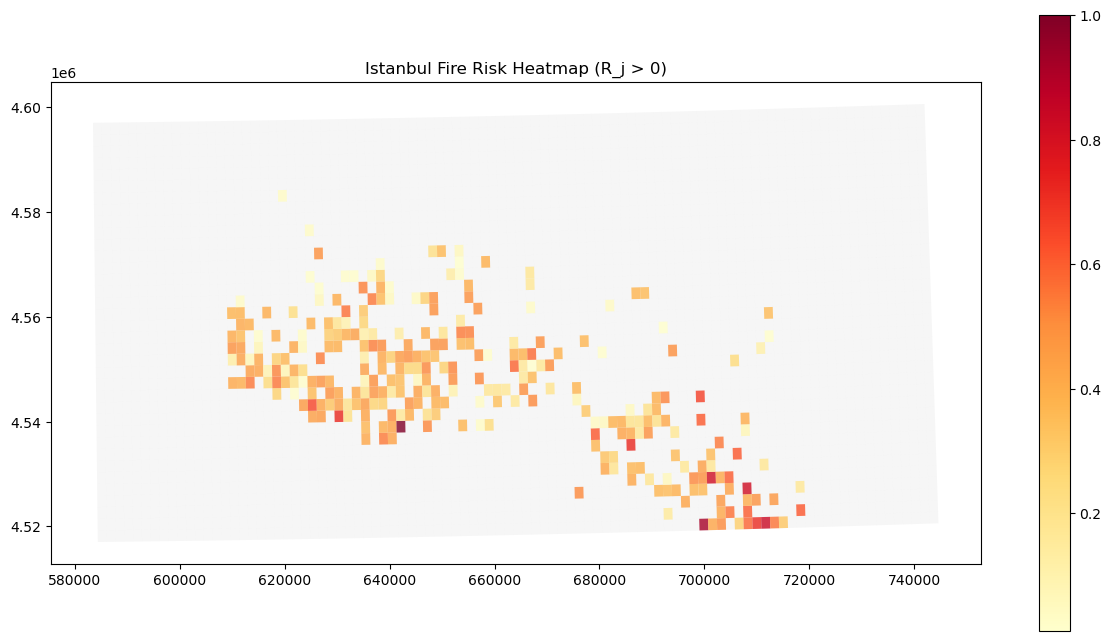

In [5]:
# Loading the calculated risk matrix
df_Rj = pd.read_csv("Rj_Risk_Matrix.csv")

# Filtering to only grid cells that have at least one fire detection
risky_grids = df_Rj[df_Rj['R_j'] > 0]
print(f"Total count of grids with positive risk: {len(risky_grids)}")

if 'gdf_grid' in locals():
    fig, ax = plt.subplots(figsize=(15, 8))

    # Drawing all Istanbul grid cells as a grey background
    gdf_grid.plot(ax=ax, color='lightgrey', alpha=0.2)

    # Overlaying only the risky cells, colored by their R_j score
    gdf_grid_risky = gdf_grid[gdf_grid['R_j'] > 0]
    gdf_grid_risky.plot(ax=ax, column='R_j', cmap='YlOrRd', legend=True,
                        markersize=15, alpha=0.8)

    plt.title("Istanbul Fire Risk Heatmap (R_j > 0)")
    plt.show()

In [6]:
df_Rj

,Grid_ID,R_j
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
...,...,...
3415,3415,0.0
3416,3416,0.0
3417,3417,0.0
3418,3418,0.0
